# Model Evaluation

This notebook contains the steps for evaluating various ML models on the PV dataset.

## 1. Receiver Operating Characteristics (ROC) and Micro-Average
- 1.1. **ROC Curve:**
    The Receiver Operating Characteristics (ROC) curve is a graphical representation of a classifier's performance across different threshold values. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.

- 1.2. **Micro-Average ROC:**
    In multi-class classification, the micro-average ROC curve is a way to evaluate the overall performance of the classifier by considering each instance equally, regardless of the class. To compute the micro-average ROC curve, the contributions of all classes are aggregated and the overall performance is measured.

In [100]:
# Import libraries
import os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Define the file path relative to the current notebook directory
base_path = os.path.join("..", "data", "processed")
results_path = os.path.join("..", "results")

# Verify that the files exist
files = ["knn_regressor_pred.csv", "knn_classifier_pred.csv", "linear_regressor_pred.csv", "naive_bayes_pred.csv", "random_forest_pred.csv",
         "logistic_regression_pred.csv", "xgb_regressor_pred.csv", "xgb_classifier_pred.csv"]
for file in files:
    if not os.path.exists(os.path.join(results_path, file)):
        raise FileNotFoundError(f"The file {file} does not exist in the directory {results_path}. Please check the path and try again.")

# Load preprocessed data
y_efficiency_test = pd.read_csv(os.path.join(base_path, "y_efficiency_test.csv"))
y_efficiency_level_test = pd.read_csv(os.path.join(base_path, "y_efficiency_level_test.csv"))
y_efficiency_level_test_int = pd.read_csv(os.path.join(base_path, "y_efficiency_level_test_int.csv"))

# Load predictions
linear_regressor_pred = pd.read_csv(os.path.join(results_path, "linear_regressor_pred.csv"))
softmax_pred = pd.read_csv(os.path.join(results_path, "logistic_regression_pred.csv"))
xgb_regressor_pred = pd.read_csv(os.path.join(results_path, "xgb_regressor_pred.csv"))
xgb_classifier_pred = pd.read_csv(os.path.join(results_path, "xgb_classifier_pred.csv"))


# Convert predictions to numpy arrays
linear_regressor_pred = linear_regressor_pred.values.ravel()
softmax_pred = softmax_pred.values.ravel()
xgb_regressor_pred = xgb_regressor_pred.values.ravel()
xgb_classifier_pred = xgb_classifier_pred.values.ravel()

# Initialize results for comparison
results = {
    "Model": [],
    "Task": [],
    "Accuracy": [],
    "F1-Score": [],
    "ROC-AUC": [],
}

def evaluate_classifier(model_name, y_true, y_true_int, y_pred_prob, y_pred_label, y_bin_test=None):
    # Ensure y_true is 1D
    y_true = y_true.values.ravel()

    # Calculate accuracy and F1-Score
    accuracy = accuracy_score(y_true, y_pred_label)
    f1 = f1_score(y_true, y_pred_label, average='weighted')

    roc_auc = None
    if y_bin_test is not None:
        # Calculate ROC-AUC for multiclass
        roc_auc = roc_auc_score(y_bin_test, y_pred_prob, multi_class="ovr", average="macro")

    # Append results
    results["Model"].append(model_name)
    results["Task"].append("Classification")
    results["Accuracy"].append(accuracy)
    results["F1-Score"].append(f1)
    results["ROC-AUC"].append(roc_auc)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_label)

    # Plot Confusion Matrix and ROC Curve
    plt.figure(figsize=(10, 6))

    # Confusion Matrix
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(model_name + " Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(np.unique(y_true)))
    plt.xticks(tick_marks, tick_marks)
    plt.yticks(tick_marks, tick_marks)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    plt.tight_layout()
    plt.show()


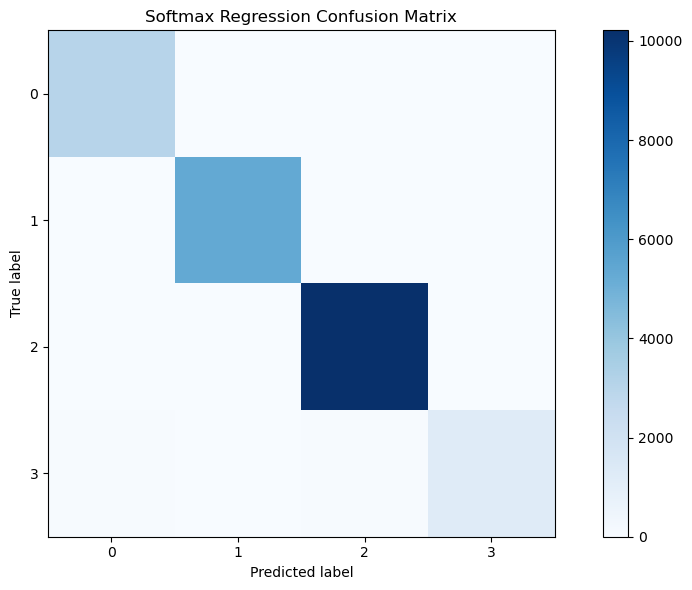

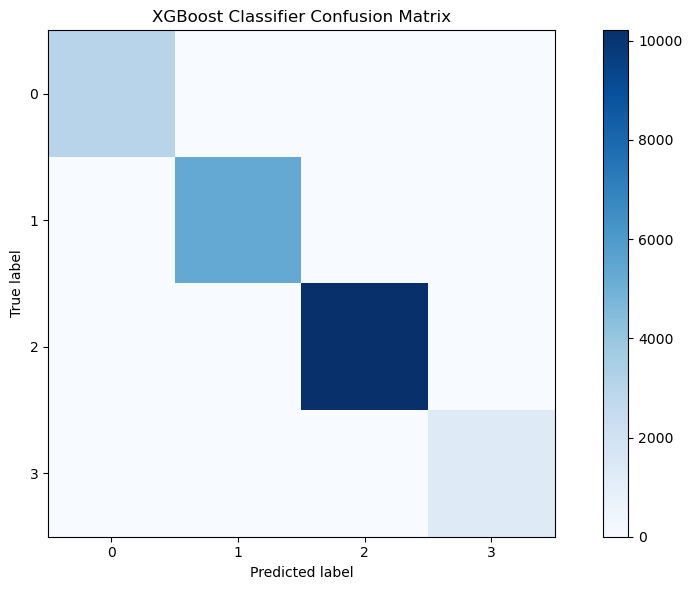


Final Results:
                Model            Task  Accuracy  F1-Score   ROC-AUC
1  XGBoost Classifier  Classification   0.99135  0.991351  0.999705
0  Softmax Regression  Classification   0.98945  0.989403  0.999705


In [101]:
class_order = np.unique(y_efficiency_level_test_int)

# Recreate y_bin_test with the correct order
y_bin_test = label_binarize(y_efficiency_level_test_int, classes=class_order)
softmax_prob = pd.read_csv(os.path.join(results_path, "logistic_regression_probabilities.csv"))
xgb_classifier_prob = pd.read_csv(os.path.join(results_path, "xgb_classifier_probabilities.csv"))
softmax_prob = softmax_prob.to_numpy() 
xgb_classifier_prob = xgb_classifier_prob.to_numpy() 

label_mapping = {
    0: 'bad',
    1: 'extremely_bad',
    2: 'good',
    3: 'moderate'
}

# Convert the XGBoost predictions to corresponding labels
xgb_classifier_labels = [label_mapping[pred] for pred in xgb_classifier_pred]

evaluate_classifier("Softmax Regression", y_efficiency_level_test, y_efficiency_level_test_int, softmax_prob, softmax_pred, y_bin_test)
evaluate_classifier("XGBoost Classifier", y_efficiency_level_test, y_efficiency_level_test_int, xgb_classifier_prob, xgb_classifier_labels, y_bin_test)
# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results)

# Display results sorted by Task and Accuracy/R²
print("\nFinal Results:")
print(results_df.sort_values(by=["Task", "Accuracy"], ascending=[True, False]))

### Conclusions from the ROC results
- Since the area under the ROC curve (AUC - Area Under the Curve) is 0.99, it indicates that the classification model has excellent performance. The AUC measures the model's ability to distinguish between classes. 

- An AUC of 0.99 suggests the model is very effective at distinguishing between positive and negative classes. Practically, this means the model has a high probability of correctly classifying a positive instance as positive and a negative instance as negative.

- An AUC of 1.0 represents a perfect model, while an AUC of 0.5 indicates a model making random classifications. An AUC of 0.99 is very close to perfect, indicating the model is making almost all predictions correctly.

- The ROC curve plots the true positive rate (TPR or sensitivity) against the false positive rate (FPR) at various thresholds. An AUC of 0.99 means that the ROC curve is very close to the upper left corner of the plot, where the TPR is high, and the FPR is low.

### Conclusions from the Confusion Matrix
- The **high values along the diagonal** indicate that the model is accurately predicting the majority of instances for each class.

- Since there is a significant difference in the number of instances between classes (class 2 has around 10 000 correct labeling cases, while class 3 has around 2 000), it might indicate **class imbalance**, which could affect the model's performance.

## Choosing the model
- **Accuracy**: The XGBoost Classifier has a slightly higher accuracy (99.110%) compared to the Softmax Regression (98.945%). Accuracy is often a good indicator of performance, so this gives XGBoost a slight edge.

- **F1-Score**: The F1-scores are very close (XGBoost: 0.991098 vs Softmax: 0.989403), so there is little practical difference between the two models in terms of the F1-score, which balances precision and recall.

- **ROC-AUC**: Both models have the same ROC-AUC values (around 0.99), meaning they perform equally well in distinguishing between the classes at different thresholds. Since this is the same for both, it doesn't provide an additional advantage.

- **Training Time**: XGBoost has a higher training time (5.61 seconds) compared to Softmax Regression (3.75 seconds). If training time is a concern for the application, we might prefer the Softmax Regression due to its faster training time, especially if the slight difference in accuracy isn't critical for the use case.

Given that both models performed similarly, we recommend using either for classifying the efficiency level of photovoltaic panels. Additionally, although it is not necessary given the results, we explore a simple deep learning model in the accompanying notebook and compare its performance against the machine learning models.